# GRUPO 7 Support Vector Machines

Fundacion universitaria los libertadores

Inteligencia Artificial 1

Actividad 2 - Exposición aprendizaje automático

- Laura Daniela Lopez Santos
- Juan Jose Narvaez Ortiz
- Dayana Michelle Pulido Moguea

---

## Introducción
En este proyecto se hara la implementación manual del algoritmo de aprendizaje supervisado Support Vector Machines (SVM). Este modelo se puede usar principalmente para rresolver problemas de clasificacion binaria.

La formulacion matematica es encontrar un hiperplano (una linea en 2D) que separe dos grupos de datos. Lo que hace que SVM sea diferente es que no busca cualquier línea al azar, si no que que busca la que este a una mayor distancia posible del margen, entre los puntos más cercanos de cada grupo, conocidos como vectores de soporte. [1]

## Fundamentos matematicos
La Máquina de Vectores de Soporte (SVM) busca encontrar un hiperplano que separe dos clases de datos maximizando el margen entre ellas haciendo uso de la funcion lineal:

$f (x) = w * x -b $

Donde:
- $w$ es el vector de pesos
- $b$ es el sesgo
- $x$ es el vector de características

La predicción se realiza evaluando el signo de esta función:

- $f(x)≥ 0$ → clase 1
- $f(x)< 0$ → clase 0

El objetivo de la SVM es que cada punto cumpla la siguiente condición:

$y_i(w * x_i - b ) ≥ 1 $

Donde:
- $y_i ∈ {-1, 1}$ es la etiqueta rreal
- $x_i$ es un punto del dataset

Esta condicion asegura que esten correctamente clasificados y ademas se encuentren fuera del margen.

Además, el modelo busca minimizar la siguiente función total:

$\frac{1}{2} \|w\|^2 + \lambda \sum max(0,1 - y_i (w * x_i - b ))$

Esta función tiene dos partes:

- $\frac{1}{2} \|w\|^2$ Minimiza la magnitud de los pesos (maximiza el margen
- $max(0,1 - y_i (w * x_i - b ))$ manejo de errores.

El proceso de aprendizaje se realiza mediante descenso de gradiente, ajustando los parámetros w y b en cada iteración:

- El punto está bien clasificado y fuera del margen:
→ solo se aplica regularización
- El punto está mal clasificado o dentro del margen:
→ se ajustan los pesos y el sesgo para corregir el error. [1], [5].

### Proceso de aprendizaje
Para entrenar el modelo, la SVM utiliza una función de costo llamada hinge loss, que mide qué tan bien el modelo está clasificando los datos.

$L (y_i, x_i) = max (0,1 - y_i(w * xi - b))$

Esta fucnion funciona de la siuiente manera

- $y_i (w * x_i - b) ≥ 1$  la perdida es 0 es decir que el punto esta bien clasificado y fuera de la imagen.
- $0 < y_i (w * x_i - b) < 1$ el punto está bien clasificado pero dentro del margen y se debe corregir.
- $y_i (w * x_i - b) < 0$ el punto esta mal clasificado se debe ajustar completamente.

La hinge loss busca solucionar los errores y también los puntos cercanos al hiperplano, lo que permite que la SVM encuentre una frontera que maximice el margen entre clases. [1], [5].

### Pseudocodigo
$$
\begin{aligned}
1:\ &\text{function SVM}(X, Y, \alpha, \lambda, \text{iteraciones}) \\
2:\ &\ (n, m) \leftarrow \text{dimensiones de } X \\
3:\ &\ w \leftarrow \mathbf{0}_m \\
4:\ &\ b \leftarrow 0 \\
5:\ &\ \text{for } i = 1 \text{ to iteraciones do} \\
6:\ &\ \quad \text{for } (idx, x_i) \in X \text{ do} \\
7:\ &\ \quad \quad \text{if } y[idx](x_i \cdot w - b) \geq 1 \text{ then} \\
8:\ &\ \quad \quad \quad w \leftarrow w - \alpha (2\lambda w) \\
9:\ &\ \quad \quad \text{else} \\
10:\ &\ \quad \quad \quad w \leftarrow w - \alpha (2\lambda w - y[idx] x_i) \\
11:\ &\ \quad \quad \quad b \leftarrow b - \alpha y[idx] \\
12:\ &\ \quad \quad \text{end if} \\
13:\ &\ \quad \text{end for} \\
14:\ &\ \text{end for} \\
15:\ &\ \text{return } (w, b) \\
16:\ &\text{end function}
\end{aligned}
$$

---

## Implementacion

In [3]:
#importar librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

En esta celda se importan las librerías necesarias para la implementación del modelo.
NumPy se utiliza para realizar operaciones matemáticas y manejo de vectores, Pandas para la manipulación de datos, y Matplotlib para la visualización gráfica.
Estas herramientas permiten implementar el algoritmo SVM desde cero sin depender de librerías de machine learning.

In [4]:
#definir funcion para entrenar el modelo
def entrenar_svm(X, y, lr=0.001, lambda_param=0.01, n_iter=2000):
    #preparar las etiquetas
    #negativa -1
    #positiva 1
    y_modificado = np.where(y <= 0, -1, 1)
    #saber numero de filas de y columnas
    n_muestras, n_caracteristicas = X.shape

    #iniciar pesos y sesgo en cero
    w = np.zeros(n_caracteristicas)
    b = 0

    #ciclo de entrenamiento
    for veces in range(n_iter):
        #recorrer cada dato
        for idx, x_i in enumerate(X):
            #formular SVM
            #verificar si el punto esta bien clasificado fuera del margen
            condicion = y_modificado[idx] * (np.dot(x_i, w) - b) >= 1

            if condicion:
                #si está bien solo se aplica la regularización
                w = w - lr * (2 * lambda_param * w)
            else:
                #si está mal ajustan los pesos y el sesgo con la formula del error
                w = w - lr * (2 * lambda_param * w - np.dot(x_i, y_modificado[idx]))
                b = b - lr * y_modificado[idx]
    return w, b

Esta función implementa el entrenamiento de una  Support Vector Machines (SVM) de forma manual, el objetivo es encontrar los parámetros $w$ (vectores) y $b$ (sesgo) que definen el hiperplano que separa las clases.

Primero, las etiquetas se transforman a valores $-1$ y $1$, ya que la formulación matemática de la SVM utiliza estos valores.
Luego se inicializan los vectores y el sesgo en cero.
El entrenamiento se realiza mediante un proceso iterativo en el que se recorren todos los datos varias veces (veces).
En cada iteración se evalúa si un punto cumple la condición del margen:

$y_i ( w * x_i - b) ≥ 1$

- se cumple → el punto está bien clasificado y solo se aplica regularización
- no se cumple → se ajustan los pesos y el sesgo para corregir el error

Este proceso corresponde a la optimización de la función de costo basada en hinge loss, la cual penaliza los errores y los puntos cercanos al margen. [1].

In [5]:
#funcion para hacer predicciones con los valores aprendidos
def predecir_svm(X, w, b):
    #calcular la posicion del punto respecto a la linea
    operacion = np.dot(X, w) - b
    #si es positivo es clase 1 si es negativo es clase 0
    return np.where(operacion >= 0, 1, 0)

Esta función utiliza los parámetros aprendidos para realizar predicciones.
Se calcula el valor de la función lineal:

$f (x) = w * x -b $

Si el resultado es mayor o igual a cero, el punto se clasifica como clase 1; en caso contrario, como clase 0, esto representa la aplicación directa del hiperplano aprendido durante el entrenamiento.

## Pruebas con dataset

In [6]:
#prueba dataset cancer
def ejecutar_modelo_svm():
    # cargar dataset desde github
    url = "https://raw.githubusercontent.com/laurad30lopezs10/Dataset-cancer/main/wdbc.data"

    # leer archivo
    data = pd.read_csv(url, header=None)

    # separar variables
    X = data.iloc[:, 2:4].values
    Y = data.iloc[:, 1].values

    # convertir etiquetas (M=0, B=1)
    Y = np.where(Y == 'M', 0, 1)

    # entrenar modelo
    vectores_finales, sesgo_final = entrenar_svm(X, Y, lr=0.001, n_iter=1000)

    # predecir
    predicciones = predecir_svm(X, vectores_finales, sesgo_final)

    # resultados
    print("Pesos encontrados:", vectores_finales)
    print("Sesgo encontrado:", sesgo_final)
    print("Primeras 10 predicciones:", predicciones[:10])

    # devolver todo para usarlo después
    return X, Y, vectores_finales, sesgo_final, predicciones

En esta función se realiza el flujo completo del modelo, comenzando con la carga del dataset desde GitHub, seguido de la selección de las características de entrada ($X$) y la transformación de las etiquetas ($Y$) a valores numéricos. Despues, se entrena el modelo utilizando la función previamente definida y se generan las predicciones correspondientes. Para facilitar la visualización, se utilizan únicamente dos características, lo que permite representar la frontera de decisión en un plano bidimensional.  En la seccion de resultados al final de la funcion se muestran los valores finales de los pesos y el sesgo, así como algunas predicciones del modelo, estos valores representan el hiperplano aprendido y permiten verificar que el modelo está funcionando correctamente.  [3].

## Visualizacion del funcionamiento

In [7]:
def graficar_frontera(X, Y, vectores_finales, sesgo_final):
    colores=['red' if y == 0 else 'lime' for y in Y]

    #puntos
    plt.scatter(X[:, 0], X[:, 1], c=colores, edgecolors='k')
    #ejes
    ax=plt.gca()
    #limites
    xlim=ax.get_xlim()
    ylim=ax.get_ylim()

    #puntos x y y
    xx=np.linspace(xlim[0], xlim[1], 30)
    yy=np.linspace(ylim[0], ylim[1], 30)

    #plano de puntos para evaluar la frontera
    yy, xx=np.meshgrid(yy, xx)
    xy=np.vstack([xx.ravel(), yy.ravel()]).T

    #funcion en el plano
    z=(np.dot(xy, vectores_finales) - sesgo_final).reshape(xx.shape)

    #hiperplano y margenes
    ax.contour(xx, yy, z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    #nombre de los ejes y titulo
    plt.title("SVM - Dataset Cáncer de Mama")
    plt.xlabel("Mean radius")
    plt.ylabel("Mean texture")
    plt.show()

Esta función permite visualizar el comportamiento del modelo SVM graficando los puntos del dataset con diferentes colores según su clase en este caso rojo para maligno y verde para benigno y generando una malla de puntos sobre el plano para evaluar la función del modelo en múltiples posiciones; a partir de estos valores se dibujan tanto la frontera de decisión como los márgenes del modelo, lo que permite observar claramente cómo se separan las clases y verificar visualmente el funcionamiento del algoritmo.

Pesos encontrados: [-0.59700584 -0.13639122]
Sesgo encontrado: -12.136999999998713
Primeras 10 predicciones: [0 0 0 1 0 1 0 1 1 1]


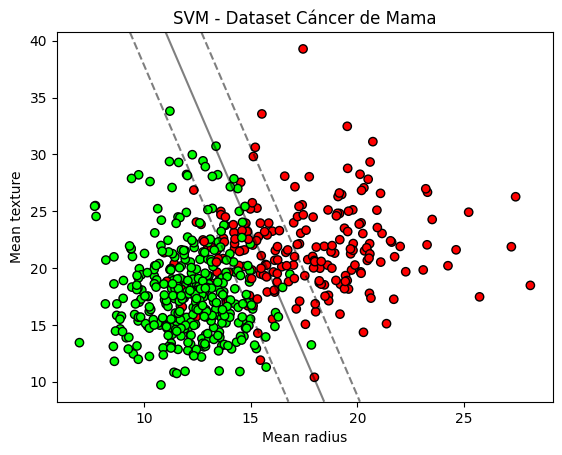

In [8]:
# ejecutar entrenamiento
X, Y, vectores_finales, sesgo_final, predicciones = ejecutar_modelo_svm()

# graficar resultado
graficar_frontera(X, Y, vectores_finales, sesgo_final)

En esta sección se ejecuta el entrenamiento del modelo SVM llamando a la función principal, la cual devuelve los datos procesados, los parámetros aprendidos (vectores y sesgo) y las predicciones generadas. Los resultados impresos muestran los valores finales del modelo, lo que indica que el algoritmo ha logrado ajustarse a los datos. Despues, se grafica la frontera de decisión junto con los puntos del dataset, donde se observa cómo el modelo separa ambas clases mediante una línea central (hiperplano) y sus márgenes. Esta visualización permite verificar de manera intuitiva que el modelo está clasificando correctamente la mayoría de los datos.

---

## Validacion de correctitud

In [9]:
#Entrenar SVM SKLEARN
def entrenar_sklearn(X, Y):
    modelo = SVC(kernel='linear')
    modelo.fit(X, Y)
    return modelo

En esta celda se define una función para entrenar un modelo SVM utilizando la librería scikit-learn, en la cual se crea un modelo con kernel lineal para obtener una frontera de decisión comparable con la implementada manualmente, luego se entrena con los datos de entrada X y sus etiquetas Y, permitiendo que el algoritmo aprenda automáticamente los parámetros óptimos del hiperplano, y finalmente se retorna el modelo entrenado para su uso en la generación de predicciones y en la posterior comparación con la implementación desde cero. [2].

In [10]:
def comparar_modelos(Y_real, pred_manual, pred_sklearn):
    acc_manual = accuracy_score(Y_real, pred_manual)
    acc_sklearn = accuracy_score(Y_real, pred_sklearn)

    coincidencias = np.sum(pred_manual == pred_sklearn)
    similitud = coincidencias / len(Y_real)

    print(f"\n{'Validacion':^30}")
    print("Accuracy manual:", acc_manual)
    print("Accuracy sklearn:", acc_sklearn)
    print("Coincidencias:", coincidencias, "de", len(Y_real))
    print("Similitud:", similitud)

    print("\nPrimeras 10 MANUAL:", pred_manual[:10])
    print("Primeras 10 SKLEARN:", pred_sklearn[:10])

En esta celda se define una función para comparar el desempeño del modelo implementado manualmente con el modelo generado mediante scikit-learn, calculando métricas como el accuracy para ambos casos, así como el número de coincidencias entre sus predicciones y el porcentaje de similitud. Además, se imprimen los resultados obtenidos junto con una muestra de las primeras predicciones de cada modelo, lo que permite evaluar tanto de forma cuantitativa como cualitativa qué tan cercana es la implementación desde cero respecto a una solución estándar. [2], [4].

In [11]:
#graficas comparativas
def graficar_comparacion(X, Y, w_manual, b_manual, modelo_sklearn):
    colores = ['red' if y == 0 else 'lime' for y in Y]

    plt.scatter(X[:, 0], X[:, 1], c=colores, edgecolors='k')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    yy, xx = np.meshgrid(yy, xx)
    xy = np.vstack([xx.ravel(), yy.ravel()]).T

    # frontera manual
    z_manual = (np.dot(xy, w_manual) - b_manual).reshape(xx.shape)

    # frontera sklearn
    z_sklearn = modelo_sklearn.decision_function(xy).reshape(xx.shape)

    # dibujar fronteras
    ax.contour(xx, yy, z_manual, colors='blue', levels=[0])
    ax.contour(xx, yy, z_sklearn, colors='green', linestyles='--', levels=[0])

    plt.title("SVM Manual vs Sklearn")
    plt.xlabel("Mean radius")
    plt.ylabel("Mean texture")

    import matplotlib.lines as mlines
    azul = mlines.Line2D([], [], color='blue', label='Manual')
    verde = mlines.Line2D([], [], color='green', linestyle='--', label='Sklearn')
    plt.legend(handles=[azul, verde])

    plt.show()

En esta celda se define una función para visualizar de forma comparativa la frontera de decisión obtenida por el modelo manual y la generada mediante scikit-learn. Primero se grafican los puntos del dataset con colores según su clase, luego se construye una malla de puntos en el plano para evaluar ambas funciones de decisión y calcular sus respectivas salidas. Con estos valores se dibujan las fronteras de decisión de cada modelo, utilizando distintos estilos para diferenciarlas, lo que permite observar visualmente qué tan similares son. Finalmente, se agregan etiquetas, título y leyenda, facilitando la interpretación y validación gráfica de que ambos modelos están aprendiendo una separación comparable.

Pesos encontrados: [-0.59700584 -0.13639122]
Sesgo encontrado: -12.136999999998713
Primeras 10 predicciones: [0 0 0 1 0 1 0 1 1 1]

          Validacion          
Accuracy manual: 0.8734622144112478
Accuracy sklearn: 0.8892794376098418
Coincidencias: 534 de 569
Similitud: 0.9384885764499121

Primeras 10 MANUAL: [0 0 0 1 0 1 0 1 1 1]
Primeras 10 SKLEARN: [0 0 0 1 0 1 0 1 1 1]


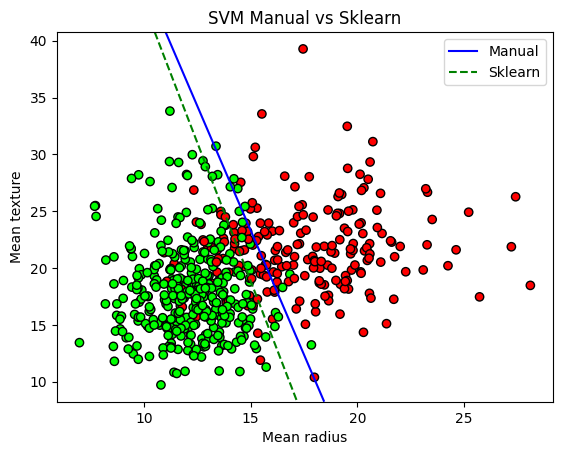

In [12]:
#ejecucion
# llamar la función que ya creaste
X, Y, vectores_finales, sesgo_final, predicciones = ejecutar_modelo_svm()

# entrenar sklearn
modelo_sklearn = entrenar_sklearn(X, Y)

# predicciones sklearn
pred_sklearn = modelo_sklearn.predict(X)

# comparar
comparar_modelos(Y, predicciones, pred_sklearn)

# graficar comparación
graficar_comparacion(X, Y, vectores_finales, sesgo_final, modelo_sklearn)

En esta celda se ejecuta el proceso completo de validación del modelo, comenzando con la llamada a la función que entrena la SVM manual y retorna los datos, parámetros y predicciones. Posteriormente, se entrena un modelo equivalente utilizando la librería scikit-learn y se generan sus predicciones para el mismo conjunto de datos. A continuación, se comparan ambos modelos mediante métricas como el accuracy, el número de coincidencias y la similitud entre predicciones, lo que permite evaluar cuantitativamente la correctitud de la implementación manual. Finalmente, se realiza una gráfica comparativa de las fronteras de decisión de ambos modelos, permitiendo verificar de forma visual que la separación aprendida es muy similar, lo que confirma que el modelo desarrollado desde cero reproduce adecuadamente el comportamiento esperado de una SVM.

---

## conclusion
En este trabajo se implementó desde cero un modelo de Máquinas de Soporte Vectorial (SVM), lo que permitió comprender su funcionamiento interno, especialmente el rol de los vectores, el sesgo y la función de costo basada en el margen (hinge loss). El modelo logró clasificar correctamente la mayoría de los datos y su comportamiento se validó mediante la comparación con scikit-learn, obteniendo resultados muy similares tanto en accuracy como en la frontera de decisión, lo que confirma que la implementación manual es correcta y evidencia la importancia de los fundamentos matemáticos en el desarrollo de modelos de machine learning.

## Referencias

[1] C. Cortes and V. Vapnik, “Support-Vector Networks,” Machine Learning, vol. 20, no. 3, pp. 273-297, 1995.

[2] Scikit-learn, “Support Vector Machines,” [Online]. Available: https://scikit-learn.org/stable/modules/svm.html

[3] UCI Machine Learning Repository, “Breast Cancer Wisconsin (Diagnostic) Dataset,” [Online]. Available: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)

[4] A. Géron, Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 2nd ed. O'Reilly Media, 2019.

[5] Wikipedia, “Support Vector Machine,” [Online]. Available: https://en.wikipedia.org/wiki/Support_vector_machine